In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
    VotingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.dpi'] = 300  

### Carga de datos

In [2]:
df_gold = pd.read_parquet('../data/gold/gold_barrios_enriquecido_test.parquet')

with open('../data/04_train_test/feature_names_v2_mejorado.json', 'r') as f:
    feature_names = json.load(f)

X = df_gold[feature_names].apply(pd.to_numeric, errors='coerce').fillna(0.0)
y = df_gold['gentrificara']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Definición de modelos candidatos
modelos = {
    'Regresión Logística (Baseline)': LogisticRegression(
        random_state=42, max_iter=1000
    ),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        class_weight='balanced',
        random_state=42,
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42
    ),
}

# Crear Ensemble Base
ensemble_base = VotingClassifier(
    estimators=[
        ('svm', modelos['SVM (RBF)']),
        ('rf', modelos['Random Forest']),
        ('gb', modelos['Gradient Boosting']),
    ],
    voting='soft',
)
modelos['Ensemble Soft Voting'] = ensemble_base

### COMPARATIVA DE RENDIMIENTO (CV K=3)

c:\Users\vande\radar-barrios\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\vande\radar-barrios\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\vande\radar-barrios\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\vande\radar-barrios\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and w

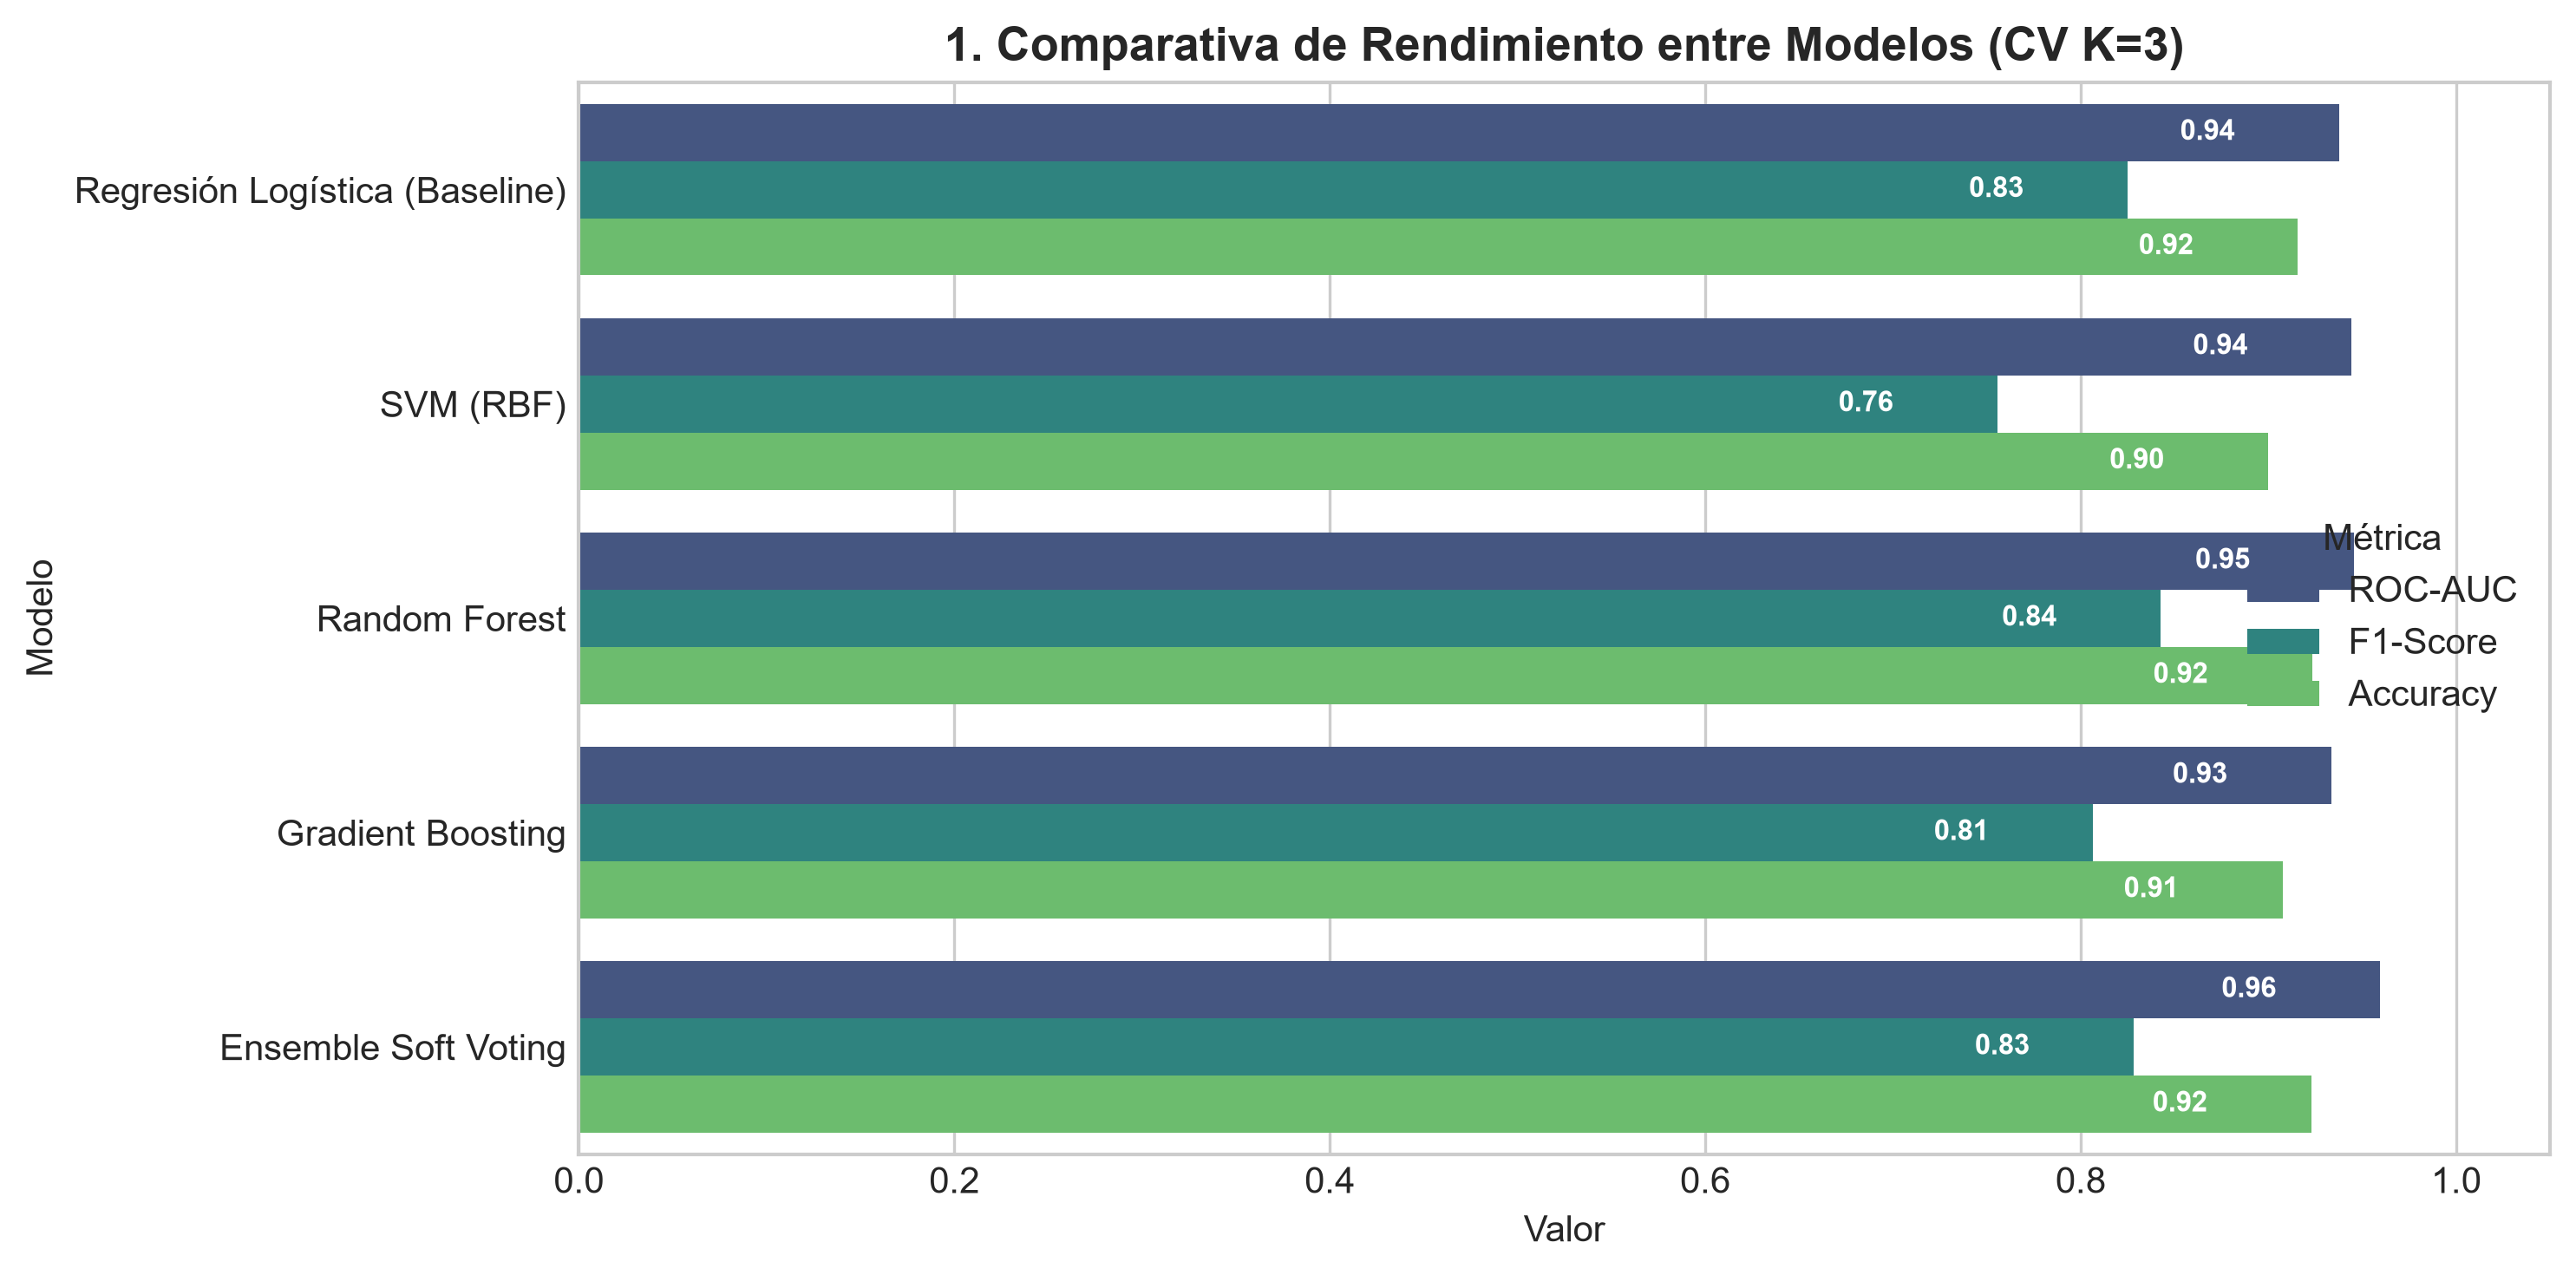

In [3]:
resultados = []
for nombre, model in modelos.items():
    cv_res = cross_validate(
        model, X_scaled, y, cv=skf, scoring=['roc_auc', 'f1', 'accuracy']
    )
    resultados.append({
        'Modelo': nombre,
        'ROC-AUC': cv_res['test_roc_auc'].mean(),
        'F1-Score': cv_res['test_f1'].mean(),
        'Accuracy': cv_res['test_accuracy'].mean(),
    })

df_res = pd.DataFrame(resultados)

fig, ax = plt.subplots(figsize=(10, 5))
df_melted = df_res.melt(
    id_vars='Modelo',
    value_vars=['ROC-AUC', 'F1-Score', 'Accuracy'],
    var_name='Métrica',
    value_name='Valor',
)
sns.barplot(
    data=df_melted,
    x='Valor',
    y='Modelo',
    hue='Métrica',
    palette='viridis',
    ax=ax,
)
ax.set_title(
    '1. Comparativa de Rendimiento entre Modelos (CV K=3)',
    fontsize=13,
    fontweight='bold',
)
ax.set_xlim(0, 1.05)
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f'{width:.2f}',
            (width - 0.07, p.get_y() + p.get_height() / 2.0),
            ha='center',
            va='center',
            color='white',
            fontweight='bold',
            fontsize=8,
        )
plt.tight_layout()
plt.savefig('01_comparativa_modelos_barras.png')
plt.show()

### CURVAS ROC SUPERPUESTAS

c:\Users\vande\radar-barrios\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\vande\radar-barrios\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\vande\AppData\Local\Temp\ipykernel_1148\773628154.py:10: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', linestyle='--', label='Clasificador Aleatorio')


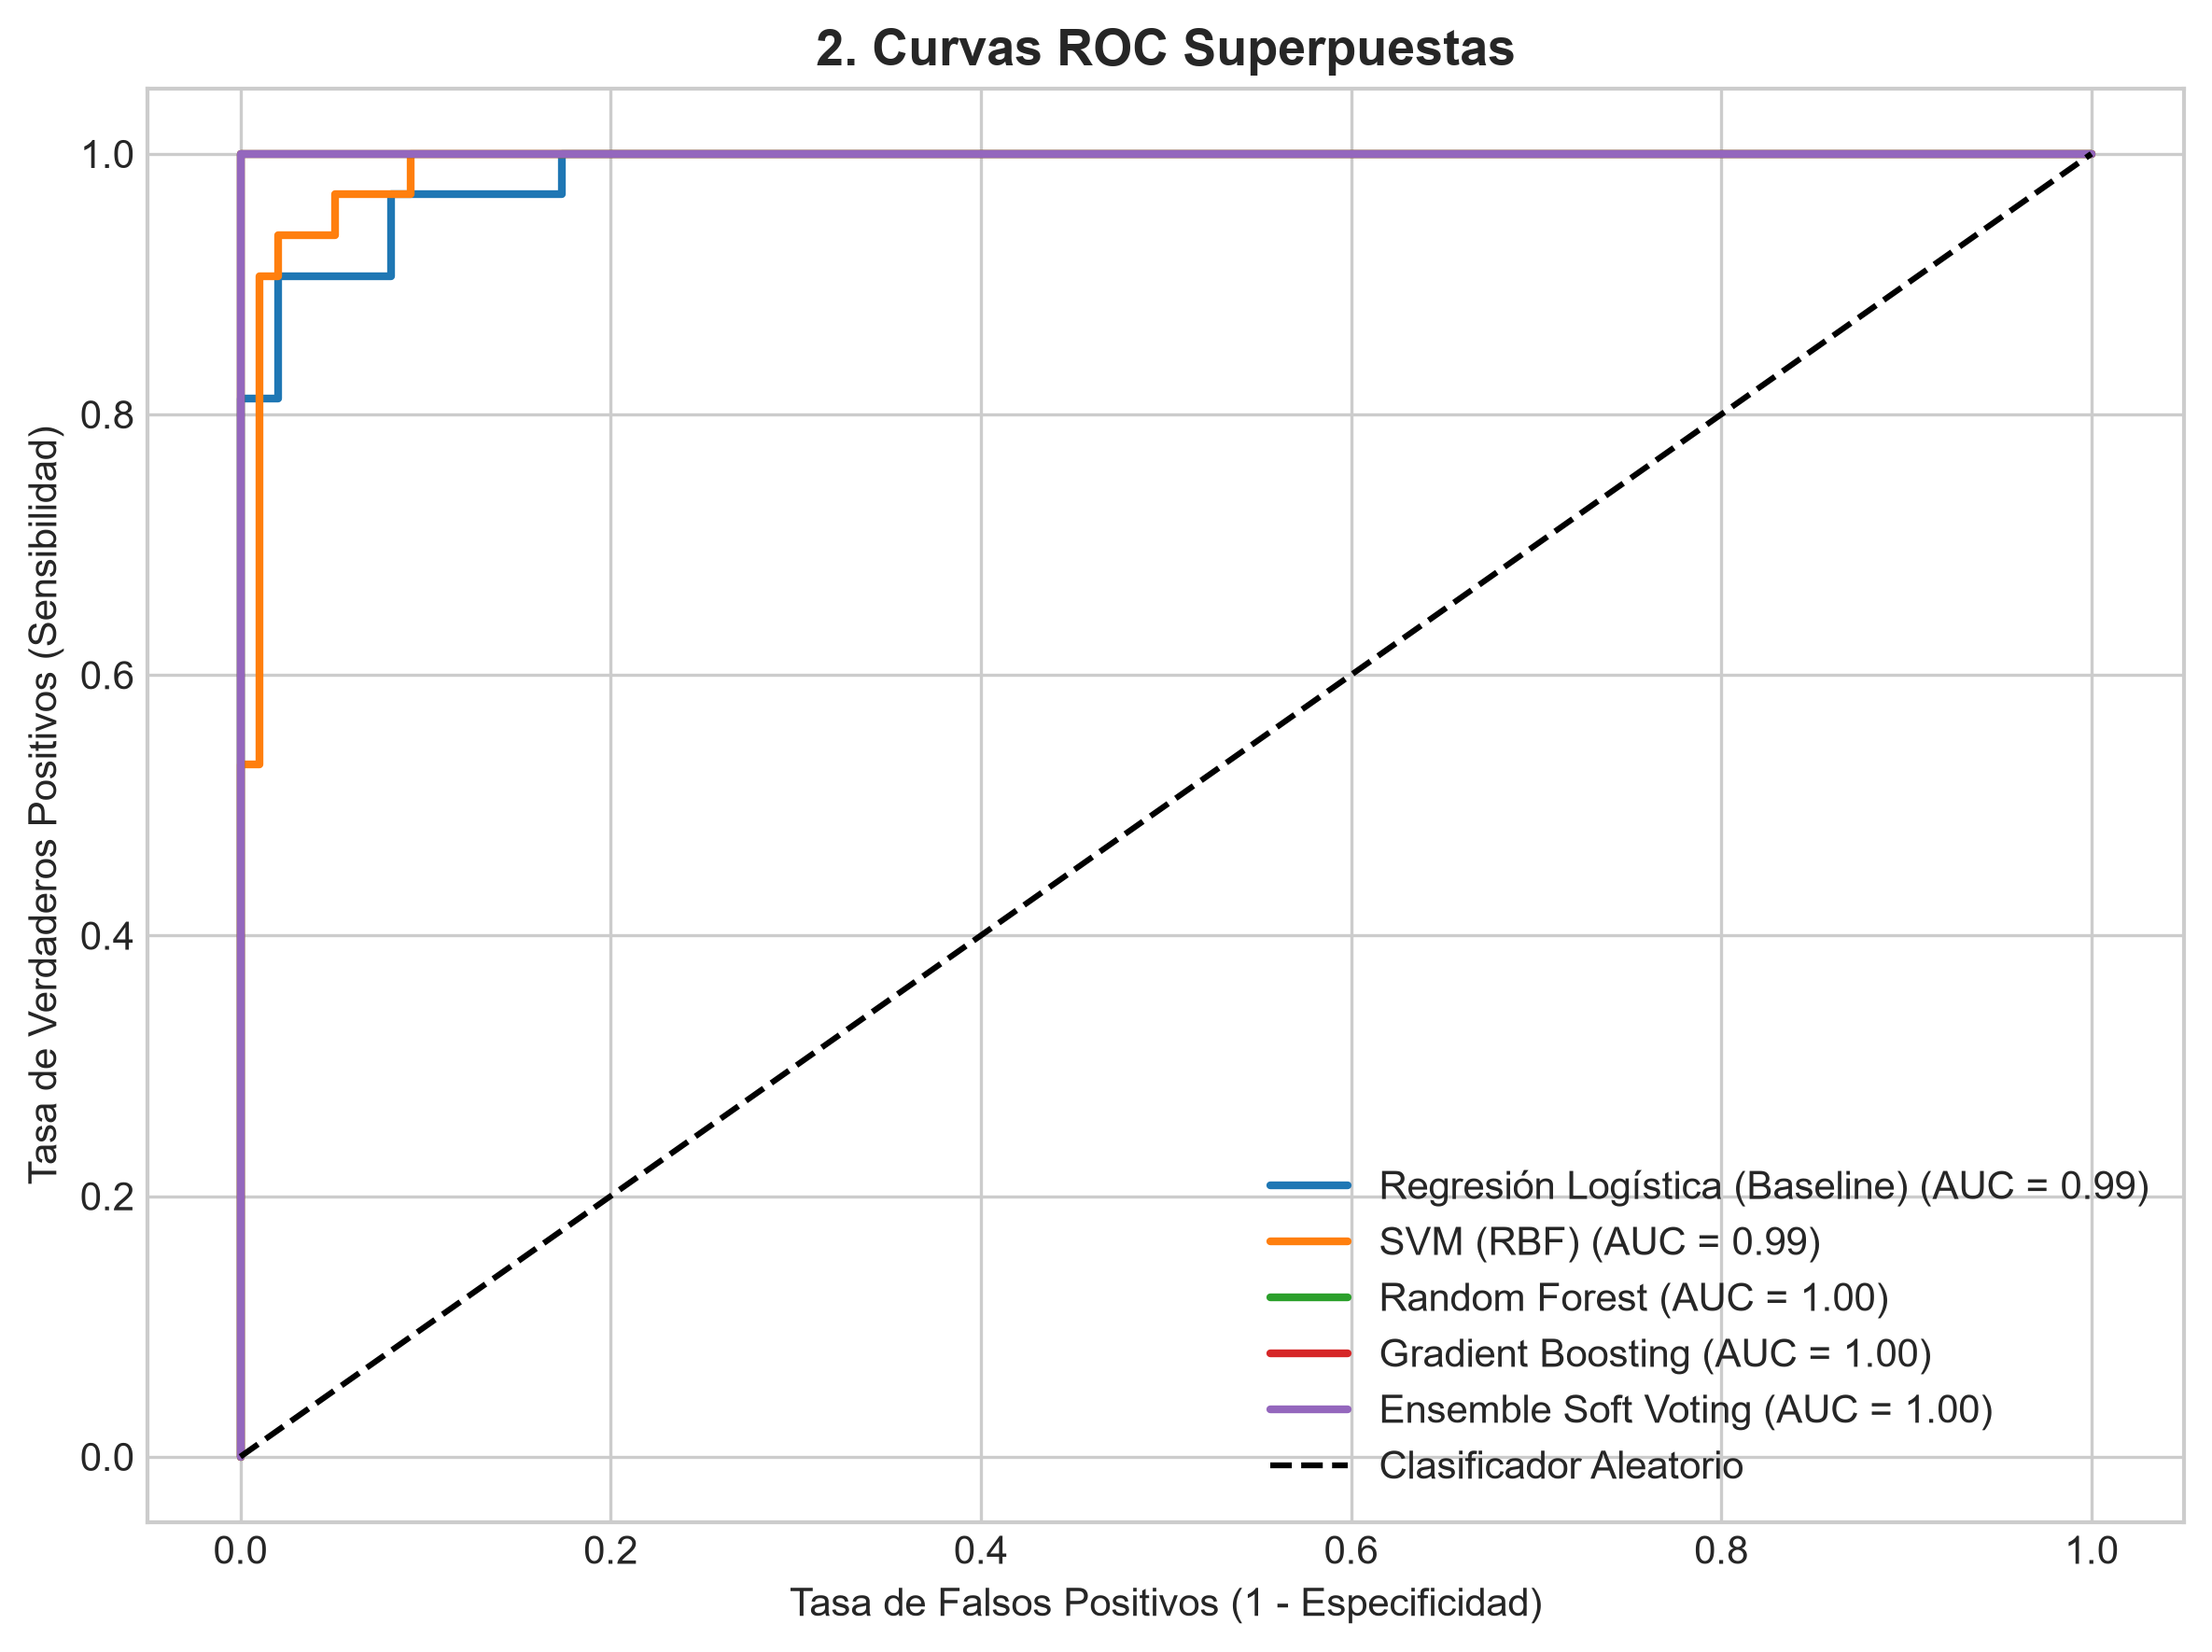

In [4]:

plt.figure(figsize=(8, 6))

for nombre, model in modelos.items():
    model.fit(X_scaled, y)
    probs_roc = model.predict_proba(X_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y, probs_roc)
    score_auc = roc_auc_score(y, probs_roc)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {score_auc:.2f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linestyle='--', label='Clasificador Aleatorio')
plt.title('2. Curvas ROC Superpuestas', fontsize=13, fontweight='bold')
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('02_curvas_roc.png')
plt.show()

### DIAGNÓSTICO DE CALIBRACIÓN DE PROBABILIDADES

c:\Users\vande\radar-barrios\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\vande\radar-barrios\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\vande\radar-barrios\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\vande\radar-barrios\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and w

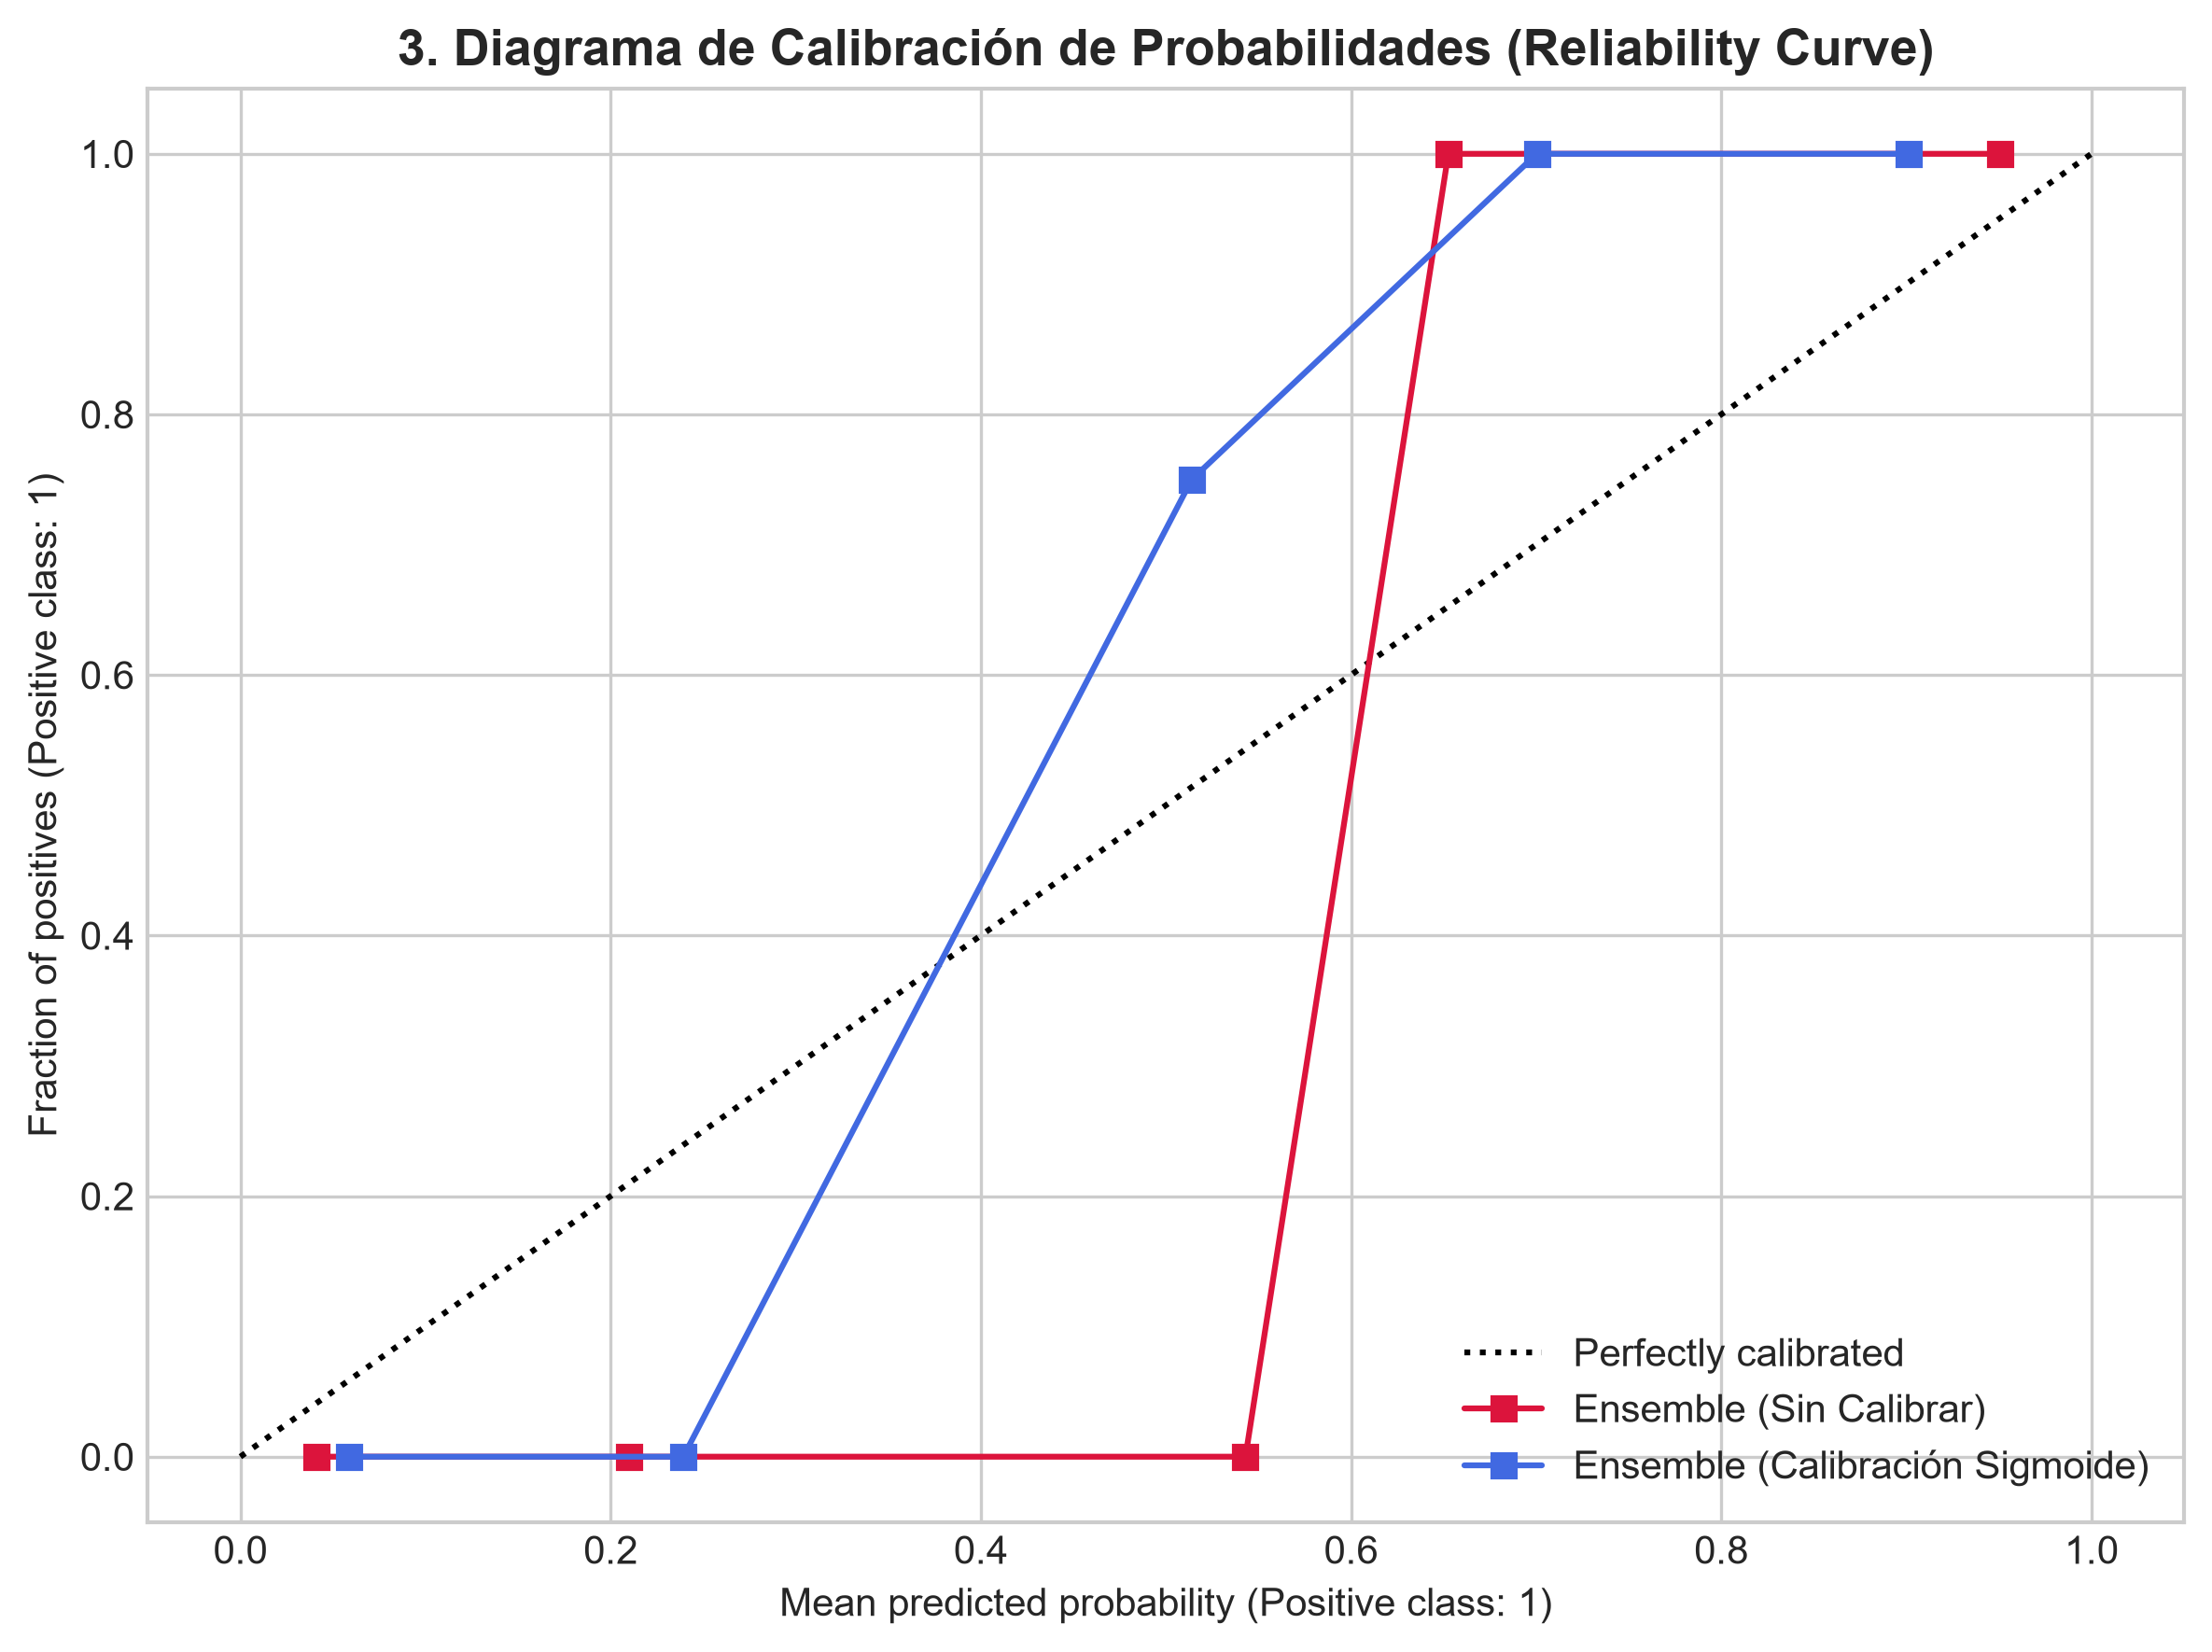

In [5]:
ensemble_base.fit(X_scaled, y)
ensemble_calibrated = CalibratedClassifierCV(
    estimator=ensemble_base, method='sigmoid', cv=skf
)
ensemble_calibrated.fit(X_scaled, y)

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_estimator(
    ensemble_base,
    X_scaled,
    y,
    n_bins=5,
    name='Ensemble (Sin Calibrar)',
    ax=ax,
    color='crimson',
)
CalibrationDisplay.from_estimator(
    ensemble_calibrated,
    X_scaled,
    y,
    n_bins=5,
    name='Ensemble (Calibración Sigmoide)',
    ax=ax,
    color='royalblue',
)

ax.set_title(
    '3. Diagrama de Calibración de Probabilidades (Reliability Curve)',
    fontsize=13,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig('03_calibracion_probabilidades.png')
plt.show()

### IMPORTANCIA DE CARACTERÍSTICAS (FEATURE IMPORTANCE)

C:\Users\vande\AppData\Local\Temp\ipykernel_1148\3954854195.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x='Importancia', y='Feature', palette='mako')


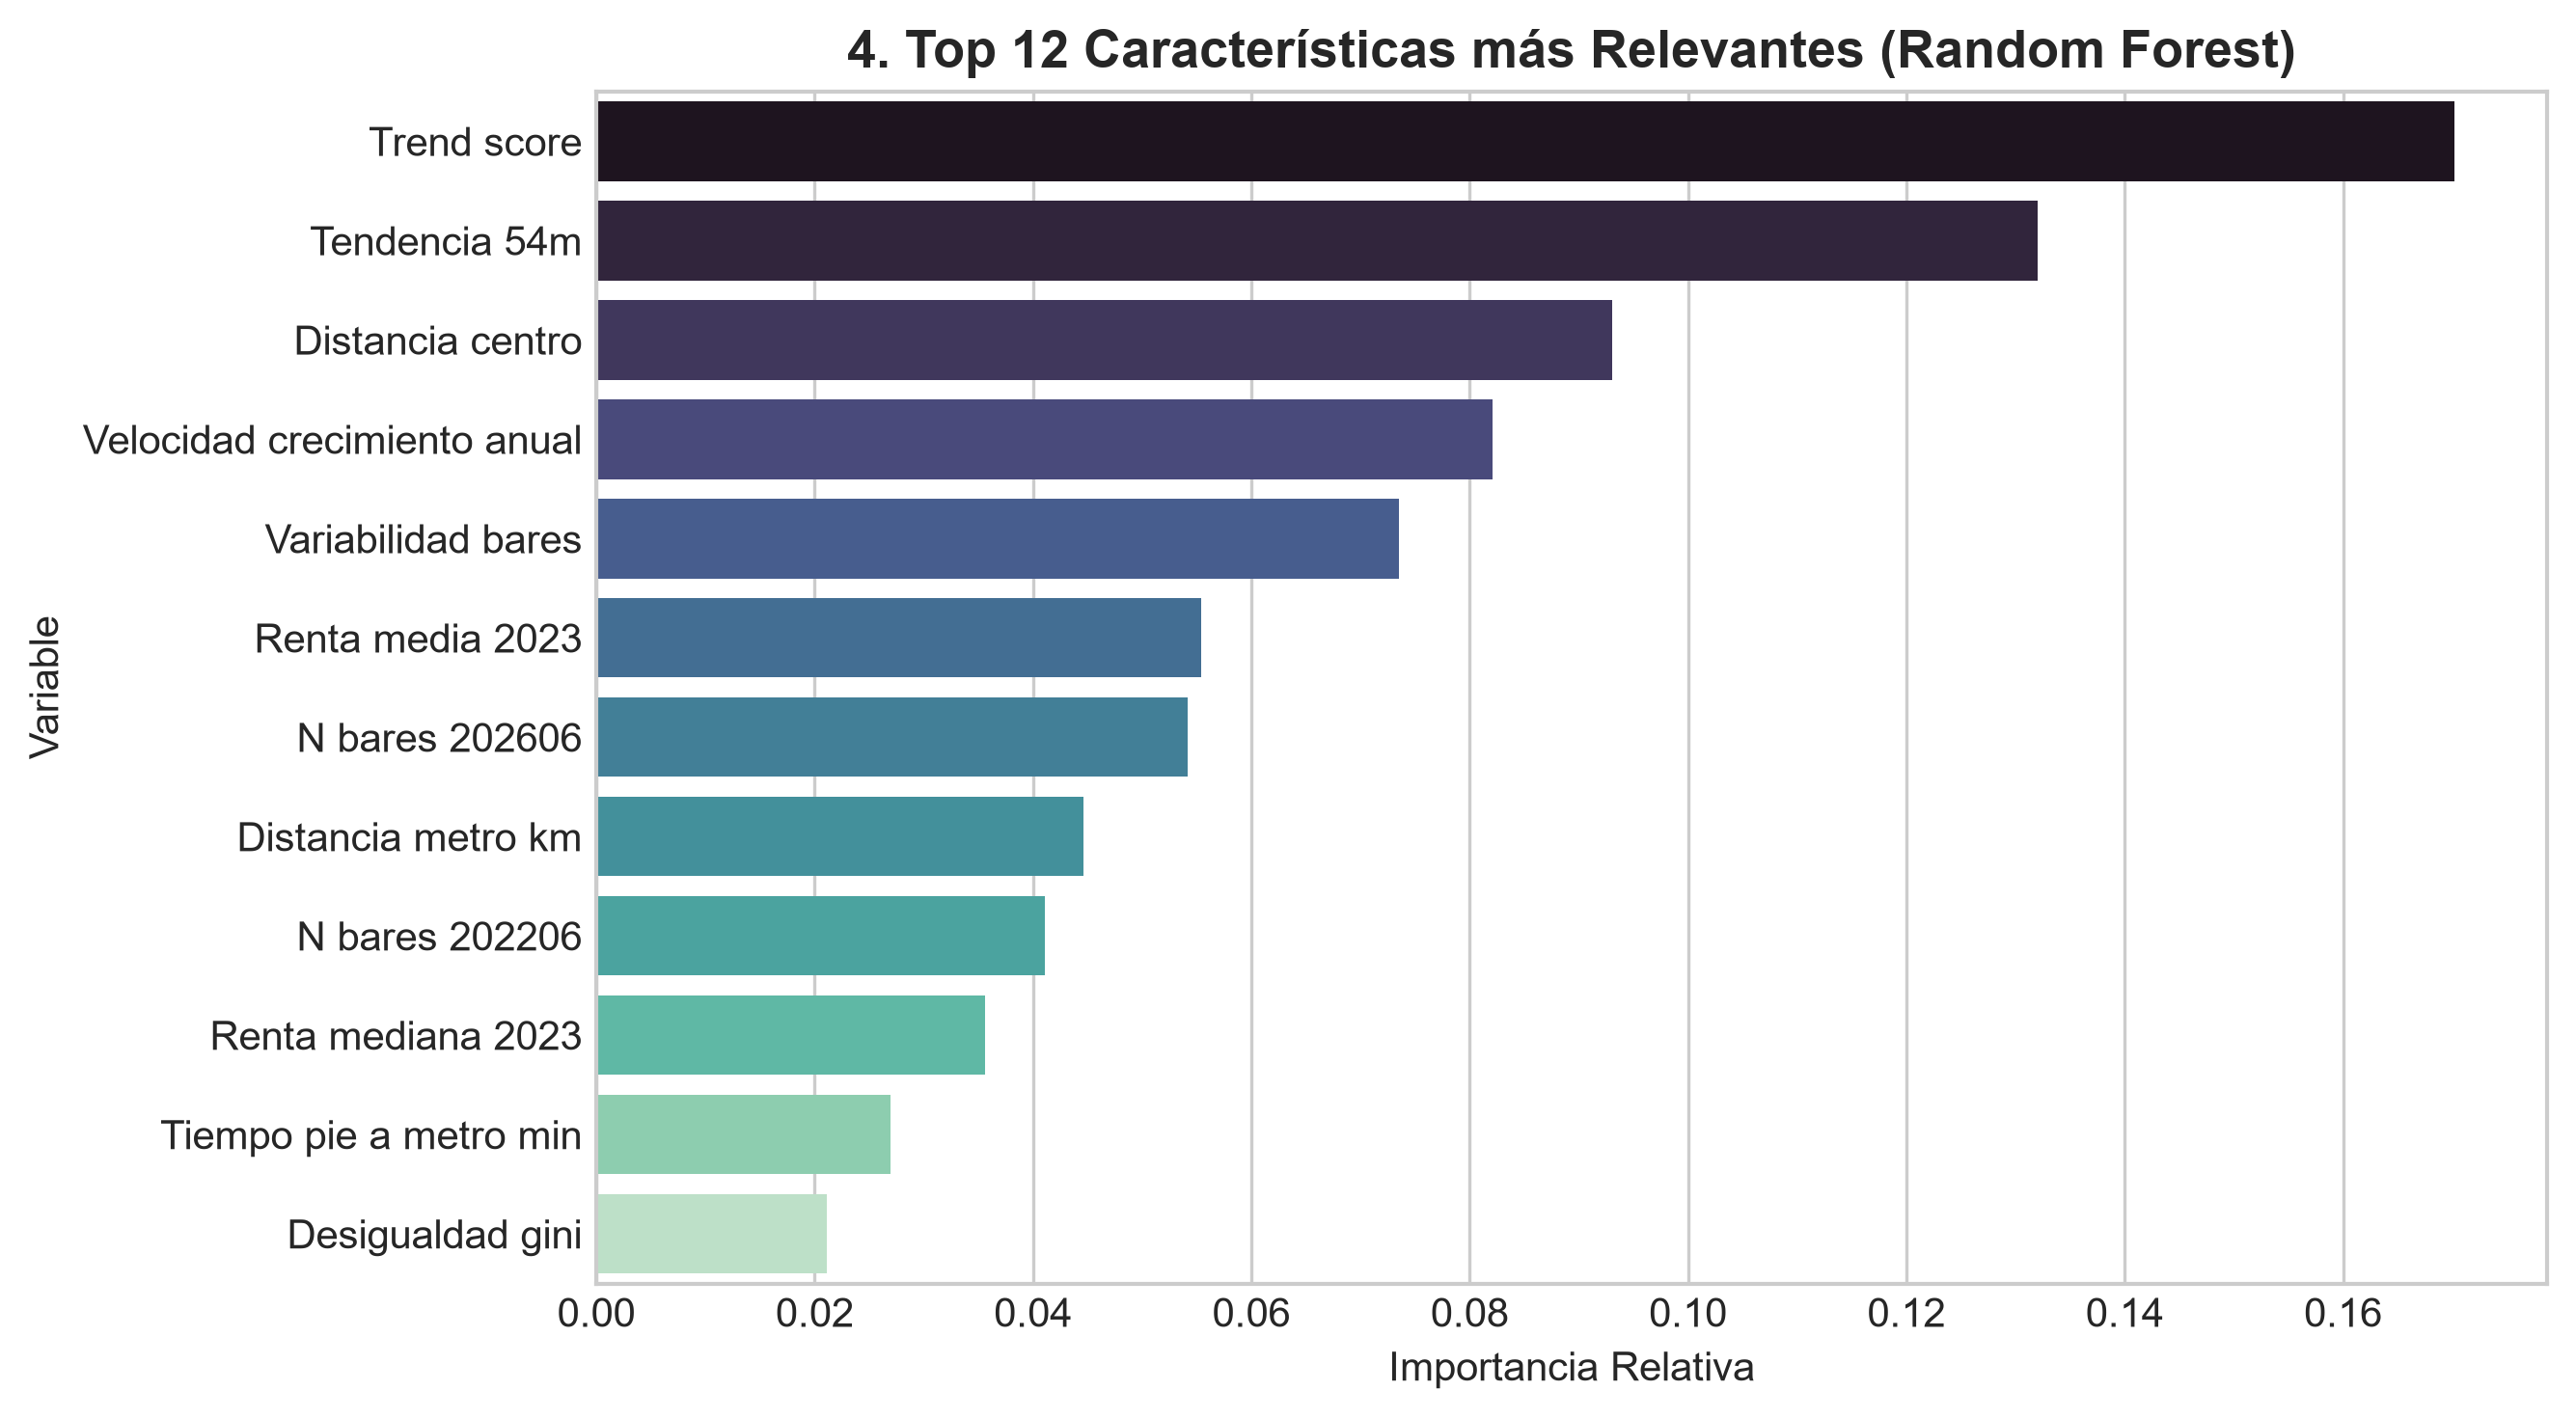

In [6]:
rf_temp = modelos['Random Forest']
rf_temp.fit(X_scaled, y)

df_imp = (
    pd.DataFrame({
        'Feature': [
            f.replace('_', ' ').capitalize() for f in feature_names
        ],  # Nombres limpios
        'Importancia': rf_temp.feature_importances_,
    })
    .sort_values(by='Importancia', ascending=False)
    .head(12)
)

plt.figure(figsize=(9, 5))
sns.barplot(data=df_imp, x='Importancia', y='Feature', palette='mako')
plt.title(
    '4. Top 12 Características más Relevantes (Random Forest)',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('Importancia Relativa')
plt.ylabel('Variable')
plt.tight_layout()
plt.savefig('04_feature_importance.png')
plt.show()

### MATRIZ DE CONFUSIÓN Y ANÁLISIS DE UMBRALES

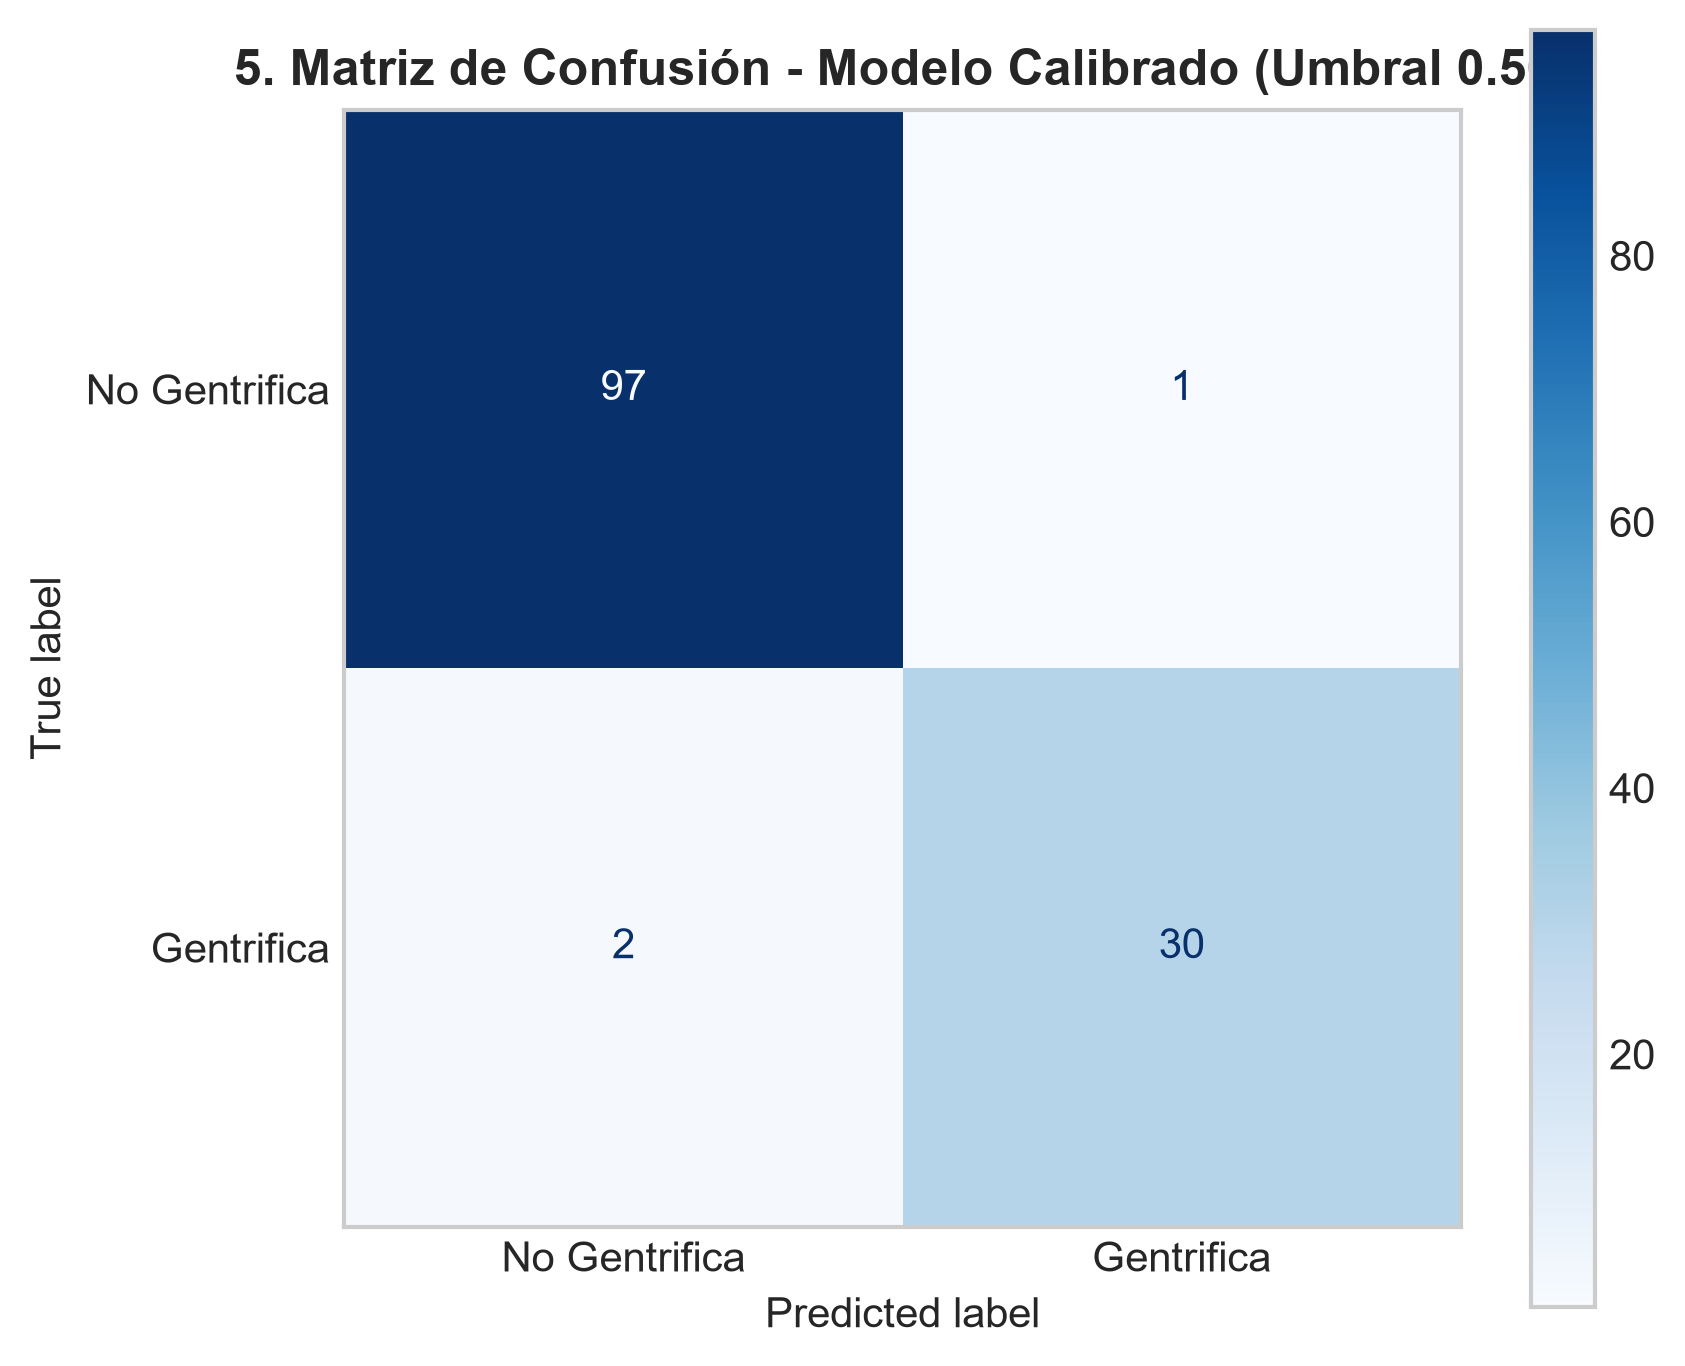

In [7]:
probs_finales = ensemble_calibrated.predict_proba(X_scaled)[:, 1]
# Umbral por defecto 0.50 para la matriz estándar
y_pred_default = (probs_finales >= 0.50).astype(int)

cm = confusion_matrix(y, y_pred_default)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=['No Gentrifica', 'Gentrifica']
)
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title(
    '5. Matriz de Confusión - Modelo Calibrado (Umbral 0.50)',
    fontsize=12,
    fontweight='bold',
)
plt.grid(False)  
plt.tight_layout()
plt.savefig('05_matriz_confusion.png')
plt.show()